imports

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

config

In [31]:
ML_DIR = Path.cwd().resolve()
PROCESSED_DIR = ML_DIR / "processed" / "heuristic_label"

X_PATH = PROCESSED_DIR / "xiangqi_X.npy"
Y_PATH = PROCESSED_DIR / "xiangqi_y.npy"
META_PATH = PROCESSED_DIR / "xiangqi_meta.csv"
MODEL_PATH = PROCESSED_DIR / "model.pt"

BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
MODEL_TYPE = "mlp"  
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

load data

In [32]:
X = np.load(X_PATH)
y = np.load(Y_PATH)
meta_df = pd.read_csv(META_PATH)

print(X.shape, y.shape, meta_df.shape)

(2200, 15, 10, 9) (2200,) (2200, 5)


split theo gameID

In [33]:
game_ids = meta_df['gameID'].astype(str).unique()
rng = np.random.default_rng(42)
rng.shuffle(game_ids)

split_idx = int(len(game_ids) * 0.8)
train_game_ids = set(game_ids[:split_idx])
val_game_ids = set(game_ids[split_idx:])

train_mask = meta_df['gameID'].astype(str).isin(train_game_ids).values
val_mask = meta_df['gameID'].astype(str).isin(val_game_ids).values

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (1745, 15, 10, 9) (1745,)
Val: (455, 15, 10, 9) (455,)


Dataset

In [34]:
class XiangqiDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, model_type="cnn"):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        self.model_type = model_type

        if model_type == "mlp":
            self.X = self.X.view(self.X.shape[0], -1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

DataLoader

In [35]:
train_ds = XiangqiDataset(X_train, y_train, model_type=MODEL_TYPE)
val_ds = XiangqiDataset(X_val, y_val, model_type=MODEL_TYPE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

DataLoader

In [36]:
class MLPValueNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

CNN

In [37]:
class CNNValueNet(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 10 * 9, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.head(self.features(x))

init model

In [38]:
if MODEL_TYPE == "mlp":
    model = MLPValueNet(train_ds[0][0].numel())
else:
    model = CNNValueNet(X.shape[1])

model = model.to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)

MLPValueNet(
  (net): Sequential(
    (0): Linear(in_features=1350, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
    (9): Tanh()
  )
)


train/eval loops

In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device, tolerance=0.2):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

        correct = (torch.abs(pred - yb) < tolerance).sum().item()
        total_correct += correct
        total_samples += xb.size(0)

    avg_loss = total_loss / len(loader.dataset)
    acc = total_correct / total_samples
    return avg_loss, acc

def evaluate(model, loader, criterion, device, tolerance=0.2):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)

            correct = (torch.abs(pred - yb) < tolerance).sum().item()
            total_correct += correct
            total_samples += xb.size(0)

    avg_loss = total_loss / len(loader.dataset)
    acc = total_correct / total_samples
    return avg_loss, acc

train

In [40]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float("inf")
best_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE, tolerance=0.2
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE, tolerance=0.2
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
    )

Epoch 1/20 | train_loss=0.0018 | val_loss=0.0016 | train_acc=0.9920 | val_acc=0.9912
Epoch 2/20 | train_loss=0.0011 | val_loss=0.0015 | train_acc=0.9920 | val_acc=0.9912
Epoch 3/20 | train_loss=0.0010 | val_loss=0.0014 | train_acc=0.9926 | val_acc=0.9912
Epoch 4/20 | train_loss=0.0007 | val_loss=0.0010 | train_acc=0.9948 | val_acc=0.9934
Epoch 5/20 | train_loss=0.0006 | val_loss=0.0008 | train_acc=0.9971 | val_acc=0.9934
Epoch 6/20 | train_loss=0.0004 | val_loss=0.0004 | train_acc=0.9989 | val_acc=0.9956
Epoch 7/20 | train_loss=0.0004 | val_loss=0.0003 | train_acc=0.9966 | val_acc=0.9978
Epoch 8/20 | train_loss=0.0001 | val_loss=0.0004 | train_acc=1.0000 | val_acc=0.9956
Epoch 9/20 | train_loss=0.0001 | val_loss=0.0003 | train_acc=0.9994 | val_acc=0.9978
Epoch 10/20 | train_loss=0.0000 | val_loss=0.0005 | train_acc=1.0000 | val_acc=0.9956
Epoch 11/20 | train_loss=0.0001 | val_loss=0.0003 | train_acc=1.0000 | val_acc=0.9978
Epoch 12/20 | train_loss=0.0000 | val_loss=0.0003 | train_acc=1

save model

In [41]:
model.load_state_dict(best_state)

torch.save({
    "model_type": MODEL_TYPE,
    "state_dict": model.state_dict(),
    "input_shape": X.shape[1:],
}, MODEL_PATH)

print("Saved:", MODEL_PATH)

Saved: C:\co-tuong-ai\backend\ml\processed\heuristic_label\model.pt


plot loss

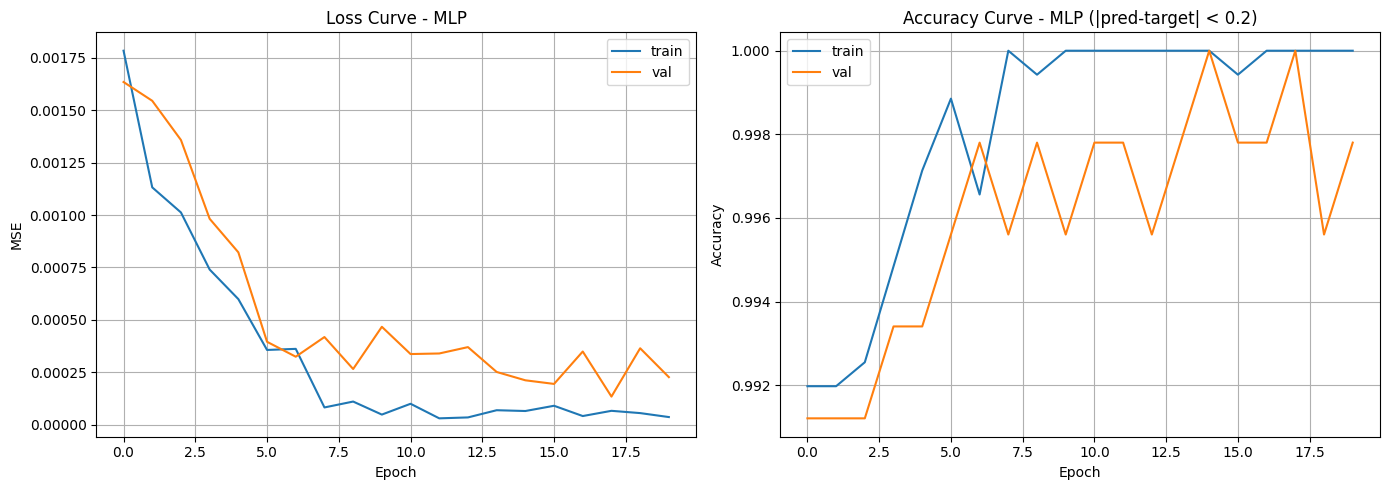

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title(f"Loss Curve - {MODEL_TYPE.upper()}")
axes[0].legend()
axes[0].grid(True)

# Accuracy curve
axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title(f"Accuracy Curve - {MODEL_TYPE.upper()} (|pred-target| < 0.2)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()